# Árvore de Regressão – Eficiência de Remédio



In [2]:
# Importação das bibliotecas necessárias
import pandas as pd                          # para manipulação de dados
from sklearn.tree import DecisionTreeRegressor, plot_tree  # modelo e visualização
from sklearn.model_selection import train_test_split       # divisão dos dados
from sklearn.metrics import mean_squared_error, r2_score   # métricas de avaliação
import matplotlib.pyplot as plt              # visualização gráfica


In [3]:
# Leitura da base de dados CSV gerada anteriormente
df = pd.read_csv("base_exemplo_regressao.csv")

# Exibição das primeiras linhas da base
df.head()


,Idade,Sexo,Dose,Peso,Altura,Dieta_Balanceada,Pratica_Exercicios,Eficiencia (%)
0,56,Feminino,62.6,72.4,1.56,Nao,Nao,20.6
1,69,Masculino,5.9,112.7,1.73,Sim,Nao,6.9
2,46,Masculino,14.6,77.2,1.60,Sim,Nao,8.8
3,32,Masculino,68.0,50.8,1.68,Nao,Sim,23.0
4,60,Masculino,5.5,113.4,1.75,Nao,Sim,2.0


In [4]:
# Transformação de variáveis categóricas em variáveis numéricas usando one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Sexo', 'Dieta_Balanceada', 'Pratica_Exercicios'], drop_first=True)

# Separação entre as variáveis preditoras (X) e a variável alvo (y)
X = df_encoded.drop('Eficiencia (%)', axis=1)
y = df_encoded['Eficiencia (%)']


In [5]:
# Divisão dos dados em conjuntos de treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # random_state garante reprodutibilidade
)


In [6]:
# Instanciação do modelo de árvore de regressão
reg = DecisionTreeRegressor(max_depth=4)  # profundidade máxima definida como 4

# Treinamento do modelo com os dados de treino
reg.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=4)

In [7]:
# Geração das previsões no conjunto de teste
y_pred = reg.predict(X_test)

# Cálculo das métricas de desempenho: erro quadrático médio (MSE) e R²
print("MSE:", mean_squared_error(y_test, y_pred))     # quanto menor, melhor
print("R²:", r2_score(y_test, y_pred))                # quanto mais próximo de 1, melhor


MSE: 30.5389695396509
R²: 0.6972819178113401


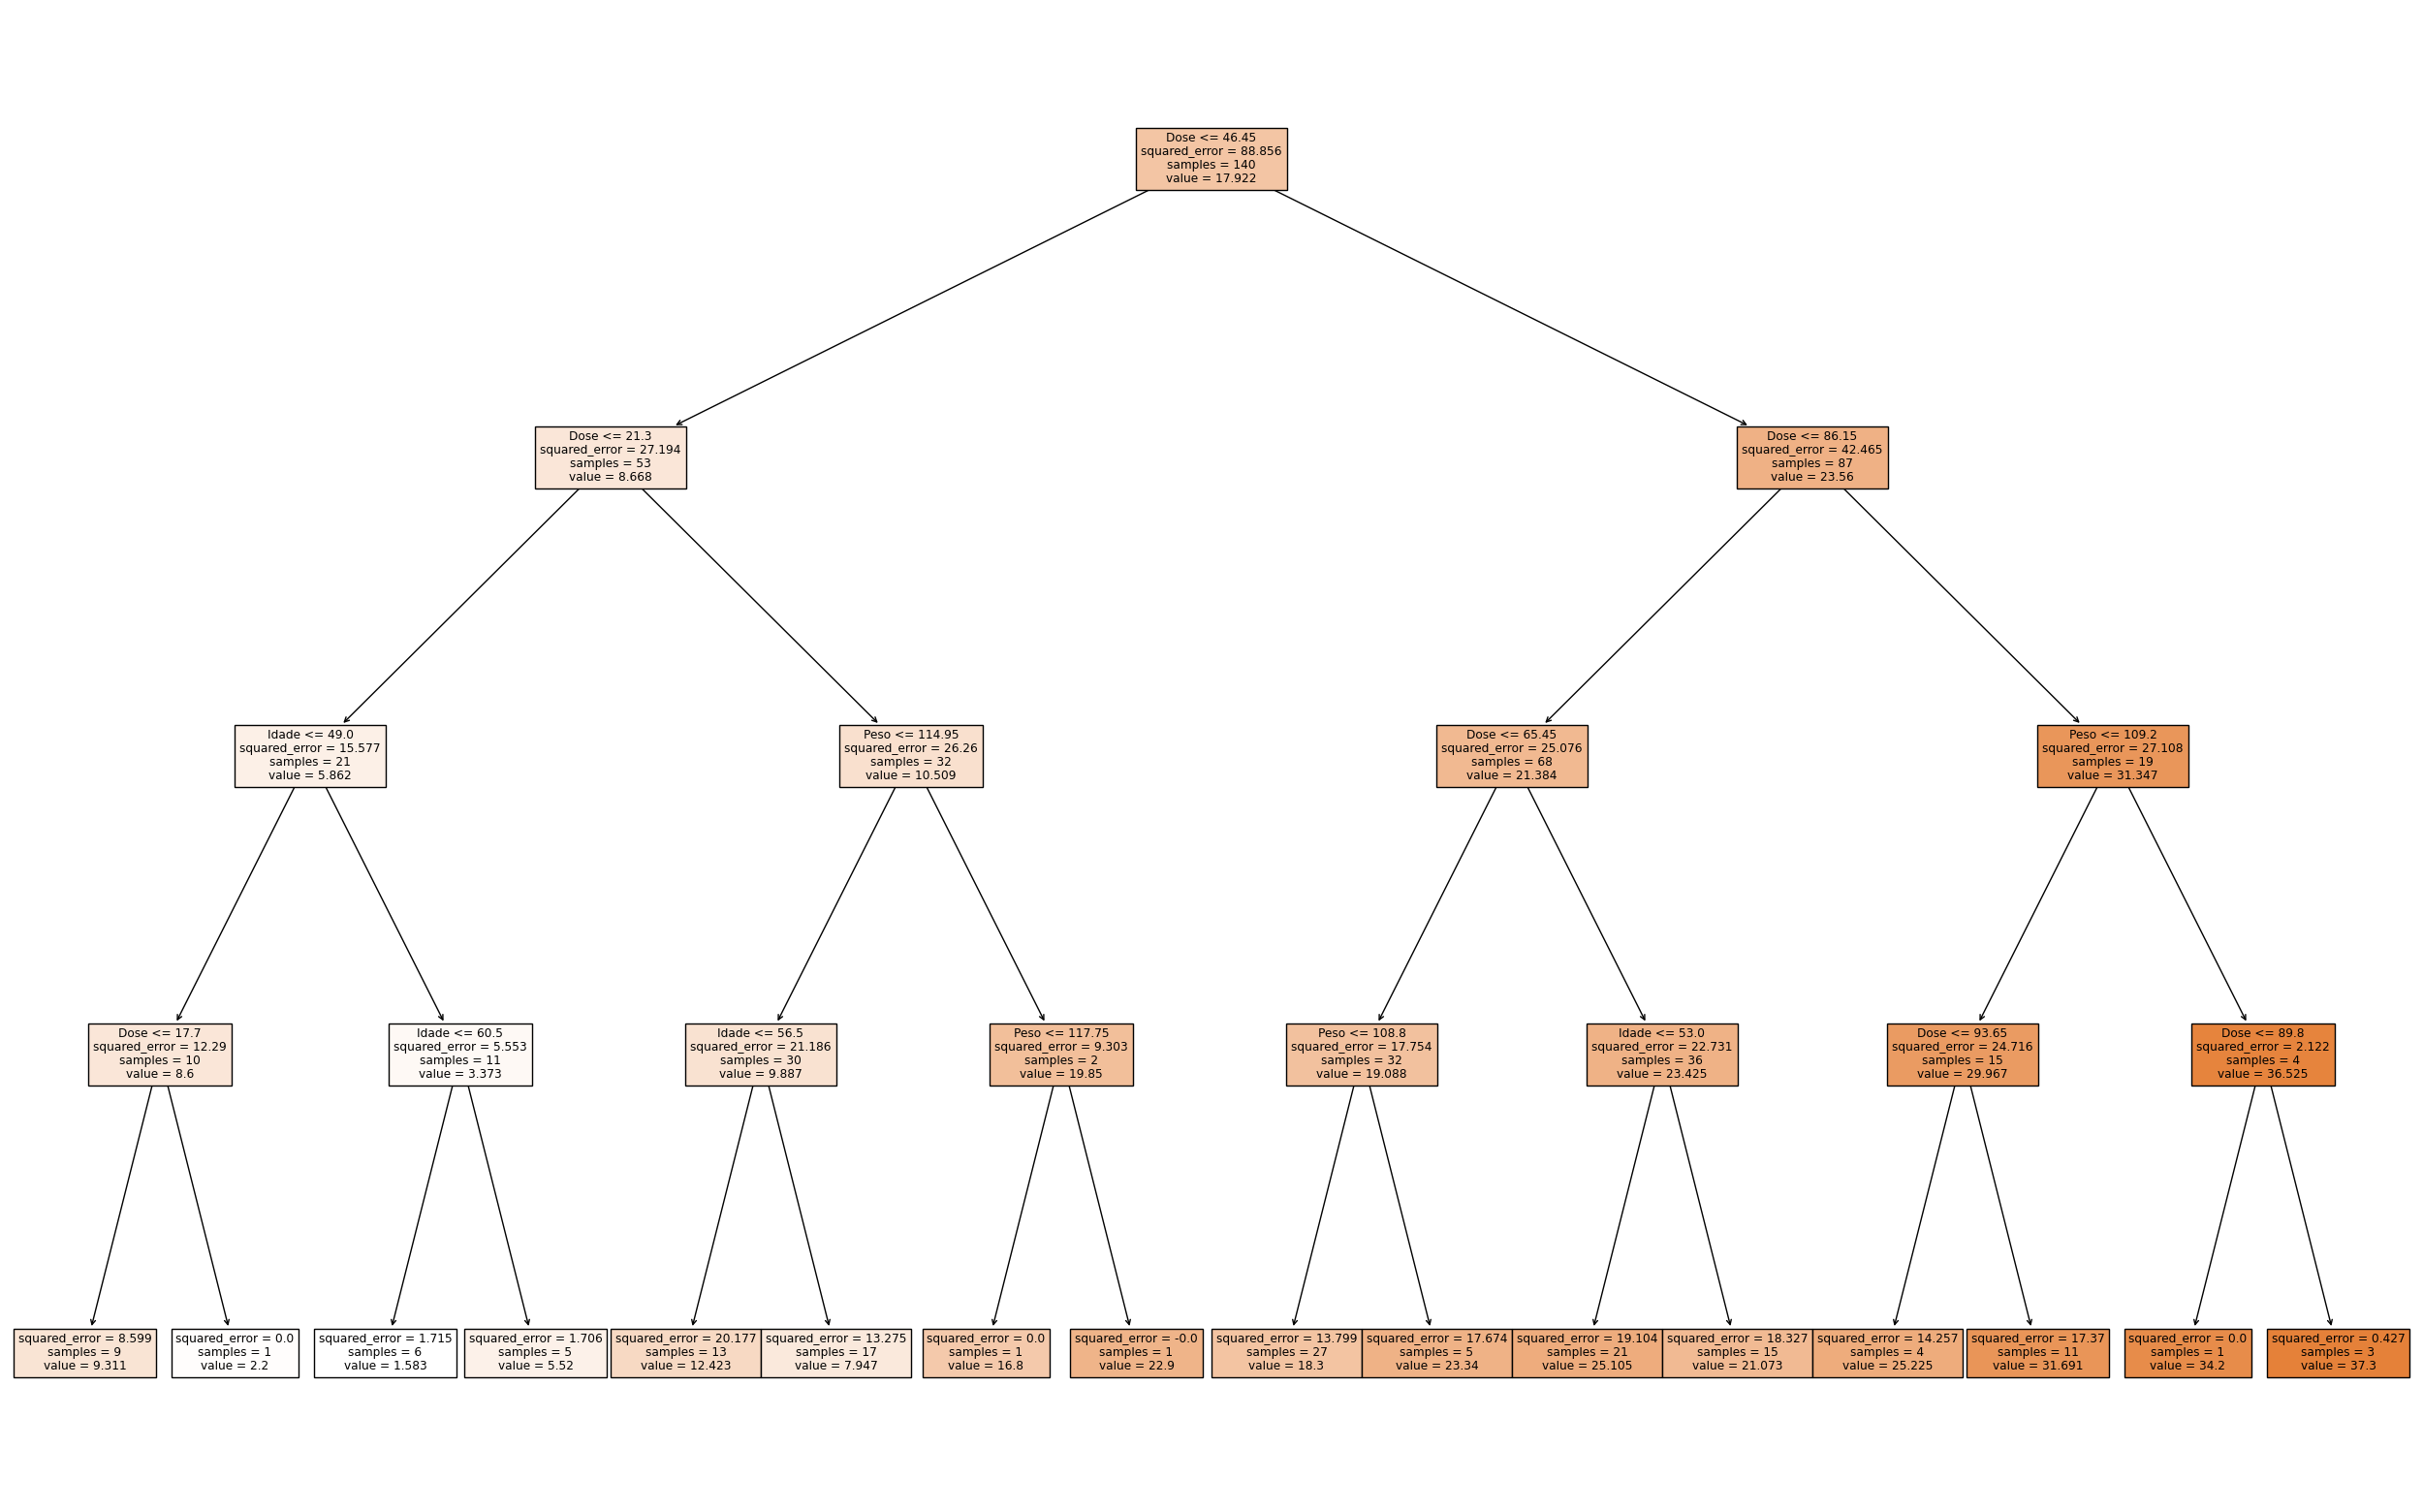

In [8]:
## Visualização gráfica da árvore de regressão treinada
plt.figure(figsize=(32, 20))                           # define tamanho do gráfico
plot_tree(reg, feature_names=X.columns, filled=True)  # exibe a árvore com cores
plt.show()
